# Лекція 4. Трансформери та мовні моделі.

## 0. Налаштування середовища

### 0.0. Імпортуємо бібліотеки

In [3]:
import sys
import os
import math
import time
import random

import numpy as np

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

### 0.1. Перевіряємо чи ми точно в Colab

In [2]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має виконуватися в Google Colab (https://colab.research.google.com/)"


Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [3]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print("Seed зафіксовано:", SEED)


Seed зафіксовано: 42


### 0.3. Використовуємо графічний прискорювач, якщо доступний.
На Colab зазвичай є безкоштовний GPU (T4).
Використовуємо його, якщо він доступний.
Якщо ні, залишаємося на CPU.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Використовуємо:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Використовуємо: cuda
GPU: Tesla T4


### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінти mini-GPT й логи TensorBoard пережили
перезапуск.

In [5]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lecture4"

os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Mounted at /content/drive
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lecture4


---
## 1. Корпус: українська поезія

Для mini-GPT з нуля потрібен текстовий корпус однією мовою, достатньо
великий, щоб модель могла вивчити бодай прості закономірності.

Використовуємо датасет [`RudyiVT/ukrainian-poems`](https://huggingface.co/datasets/RudyiVT/ukrainian-poems)
(17 918 віршів, 757 авторів, зібрано з [ukrlib.com.ua](https://www.ukrlib.com.ua/))
повністю — весь текст іде в один суцільний корпус для тренування.

### 1.1. Завантажуємо датасет з Hugging Face Hub

In [6]:
from datasets import load_dataset

poems_dataset = load_dataset("RudyiVT/ukrainian-poems", split="train")
print("Усього віршів у датасеті:", len(poems_dataset))
print("Колонки:", poems_dataset.column_names)


README.md:   0%|          | 0.00/695 [00:00<?, ?B/s]

data/train-00000-of-00001-3d92810ccd3206(…): reconstructing file:   0%|          |  0.00B / 58.6MB            

data/train-00000-of-00001-3d92810ccd3206(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/17918 [00:00<?, ? examples/s]

Усього віршів у датасеті: 17918
Колонки: ['author', 'author_url', 'poem_name', 'poem_url', 'context_author', 'context_poem_name', 'context_poem']


### 1.2. Збираємо суцільний корпус

In [7]:
poems_df = poems_dataset.to_pandas()
corpus_text = "\n\n".join(poems_df["context_poem"].dropna().tolist())

print("Розмір корпусу:", len(corpus_text), "символів")
print("Перші 500 символів корпусу:\n", corpus_text[:500])

Розмір корпусу: 60886196 символів
Перші 500 символів корпусу:
 У гостинній бавилися розмовою три добре знайомі особи.

Обі панночки торочили свою звичайну, мляву розмову, мололи дрібними язичками, як на коловороті, закрашували забаву штучними, але пустими дотепами, перекидалися за-мітними поглядами, переплітали невинну розмову більше або менше невинними сплетнями.

Він сидів набоці вигідно у кріслі, слухав оклепаного розговору і банальних дотепів, нудився і... від часу до часу зівав.

Думав свою думку і впертим мовчанням, себто маломов-ністю, в товаристві д


### 1.3. Базова статистика корпусу

In [8]:
words = corpus_text.split()
unique_words = set(w.lower() for w in words)

print("Слів (з повторами):   ", len(words))
print("Унікальних слів:      ", len(unique_words))
print("Приклад уривку:\n")
print(corpus_text[:500])


Слів (з повторами):    9941806
Унікальних слів:       994965
Приклад уривку:

У гостинній бавилися розмовою три добре знайомі особи.

Обі панночки торочили свою звичайну, мляву розмову, мололи дрібними язичками, як на коловороті, закрашували забаву штучними, але пустими дотепами, перекидалися за-мітними поглядами, переплітали невинну розмову більше або менше невинними сплетнями.

Він сидів набоці вигідно у кріслі, слухав оклепаного розговору і банальних дотепів, нудився і... від часу до часу зівав.

Думав свою думку і впертим мовчанням, себто маломов-ністю, в товаристві д


---
## 2. Токенізація: BPE на власному корпусі

Токенізація перетворює текст на послідовність id. Використовуємо BPE (Byte Pair Encoding),
який досить часто використовується на великих LLM. Тренуємо через `tokenizers` (від HuggingFace)—
переписувати цикл злиття пар вручну немає сенсу: це вже готовий, швидкий (Rust) алгоритм,
а не нова концепція, яку ми тут вивчаємо.

### 2.1. Тренуємо BPE

Тренер бачить датасет як список окремих віршів (а не один суцільний
рядок) — це і природніший спосіб виклику `train_from_iterator`, і легший
для пам'яті: не потрібно тримати весь корпус як один текстовий блок під
час підрахунку частот пар.

In [9]:
VOCAB_SIZE = 16000
SPECIAL_TOKENS = ["<unk>", "<eos>"]

from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

bpe_tokenizer = Tokenizer(models.BPE(unk_token="<unk>"))
bpe_tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
bpe_tokenizer.decoder = decoders.ByteLevel()

bpe_trainer = trainers.BpeTrainer(vocab_size=VOCAB_SIZE, special_tokens=SPECIAL_TOKENS)
poems_iterator = poems_df["context_poem"].dropna().tolist()
bpe_tokenizer.train_from_iterator(poems_iterator, trainer=bpe_trainer)
del poems_iterator

bpe_vocab = bpe_tokenizer.get_vocab()
itos = [None] * len(bpe_vocab)
for tok, idx in bpe_vocab.items():
    itos[idx] = tok
stoi = bpe_vocab
UNK_ID = stoi["<unk>"]

def tokenize(text: str) -> list[str]:
    return bpe_tokenizer.encode(text).tokens

def encode(tokens: list[str]) -> list[int]:
    return [stoi.get(t, UNK_ID) for t in tokens]

def decode(ids: list[int]) -> str:
    return bpe_tokenizer.decode(ids)

print("Розмір словника (BPE):", len(itos))

Розмір словника (BPE): 16000


### 2.2. Кодуємо корпус у послідовність id

Кодуємо пачками (`.encode_batch()`) по кілька сотень віршів, одразу перетворюючи кожен
результат на компактний `numpy` масив (`int32`, 4 байти на токен). Один
виклик `encode()` на весь корпус одразу тримає у пам'яті і список токенів,
і список id для всього тексту разом, що може призвести до вичерпання памʼяті (out of memory, OOM).

In [10]:
import gc
import numpy as np

ENCODE_BATCH_SIZE = 1000
EOS_ID = stoi["<eos>"]
poems_list = poems_df["context_poem"].dropna().tolist()

token_id_chunks = []
for start in range(0, len(poems_list), ENCODE_BATCH_SIZE):
    batch = poems_list[start:start + ENCODE_BATCH_SIZE]
    encodings = bpe_tokenizer.encode_batch(batch)
    for enc in encodings:
        # <eos> позначає межу між віршами — без цього при конкатенації
        # останній токен одного вірша впритул стикається з першим токеном
        # наступного, і модель бачить один суцільний текст замість окремих творів.
        token_id_chunks.append(np.array(enc.ids + [EOS_ID], dtype=np.int32))
    del encodings
del poems_list
gc.collect()

token_ids = np.concatenate(token_id_chunks)
del token_id_chunks
gc.collect()

unk_share = (token_ids == UNK_ID).mean()
print(f"Токенів у корпусі (обраний токенізатор): {len(token_ids)}")
print(f"Токенів поза словником (<unk>): {unk_share:.1%}")

data = torch.from_numpy(token_ids.astype(np.int64))
del token_ids
gc.collect()
print("Форма закодованого корпусу:", data.shape)

Токенів у корпусі (обраний токенізатор): 18421968
Токенів поза словником (<unk>): 0.0%
Форма закодованого корпусу: torch.Size([18421968])


### 2.3. Спліт train/val

Для тексту спліт робимо **послідовним** зрізом, а не випадковим
перемішуванням рядків — модель тренується передбачати "наступне слово",
тому послідовність токенів має лишатись цілою.

In [11]:
split_idx = int(len(data) * 0.9)
train_data = data[:split_idx]
val_data = data[split_idx:]

print("train:", train_data.shape, " val:", val_data.shape)

train: torch.Size([16579771])  val: torch.Size([1842197])


---
## 3. Mini-GPT з нуля

Реалізуємо decoder-only трансформер "з нуля" — так, як на слайдах лекції:
Query/Key/Value власноруч, без `nn.MultiheadAttention` як чорної скриньки.

Модель навмисно маленька: мета — побачити механіку і криву навчання,
а не отримати практично корисний генератор тексту. Тренування вкладається
у 1.5-2 години на безкоштовному Colab T4.

### 3.1. Гіперпараметри

In [12]:
CONTEXT_LEN = 64        # скільки попередніх токенів бачить модель
EMBED_DIM = 128         # розмірність embedding
N_HEADS = 4             # кількість attention-голів
N_LAYERS = 4            # кількість блоків трансформера
DROPOUT = 0.1           # рівень dropout для регуляризації
BATCH_SIZE = 64         # розмір батчу
LEARNING_RATE = 3e-4    # швидкість навчання
MAX_ITERS = 8000        # кількість ітерацій навчання
EVAL_INTERVAL = 250     # інтервал (в ітераціях) для оцінки моделі на валідаційній вибірці
EVAL_ITERS = 50         # кількість ітерацій для оцінки на валідаційній вибірці

assert EMBED_DIM % N_HEADS == 0, "EMBED_DIM має ділитися на N_HEADS"
HEAD_DIM = EMBED_DIM // N_HEADS


### 3.2. Батчі: випадкові вікна контексту

Кожен приклад — випадковий зріз довжини `CONTEXT_LEN` з корпусу; таргет —
той самий зріз, зсунутий на один токен вперед (передбачаємо наступне слово
для кожної позиції одночасно).

In [13]:
def get_batch(split: str, return_idx: bool = False):
    source = train_data if split == "train" else val_data
    ix = torch.randint(len(source) - CONTEXT_LEN - 1, (BATCH_SIZE,))
    x = torch.stack([source[i:i + CONTEXT_LEN] for i in ix])
    y = torch.stack([source[i + 1:i + CONTEXT_LEN + 1] for i in ix])
    x, y = x.to(device), y.to(device)
    return (x, y, ix) if return_idx else (x, y)

xb, yb = get_batch("train")
print("Форма батчу x:", xb.shape, " y:", yb.shape)

# --- assert-тест (завдання 0.1, п. 6): частини випадкового батчу узгоджені між собою і з корпусом ---
xb, yb, ix = get_batch("train", return_idx=True)
assert xb.shape == yb.shape == (BATCH_SIZE, CONTEXT_LEN)                 # правильна форма
assert torch.equal(xb[:, 1:], yb[:, :-1])                                # y — це x, зсунутий на 1 токен уперед
for row, i in enumerate(ix.tolist()):                                    # кожен рядок — суцільний зріз train_data
    assert torch.equal(xb[row].cpu(), train_data[i:i + CONTEXT_LEN])
    assert torch.equal(yb[row].cpu(), train_data[i + 1:i + CONTEXT_LEN + 1])
assert 0 <= int(xb.min()) and int(xb.max()) < len(itos)                  # id токенів у межах словника
print("assert-тести батчу: OK")

Форма батчу x: torch.Size([64, 64])  y: torch.Size([64, 64])
assert-тести батчу: OK


### 3.3. Одна attention-голова

Наведемо формулу attention:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

До неї додаємо **причинну маску** (`causal mask`), адже токен на позиції `t` не має права
"дивитися" на токени після себе, інакше модель підглядає відповідь.

In [14]:
class AttentionHead(nn.Module):
    def __init__(self, embed_dim: int, head_dim: int, context_len: int, dropout: float):
        super().__init__()
        self.query = nn.Linear(embed_dim, head_dim, bias=False)
        self.key = nn.Linear(embed_dim, head_dim, bias=False)
        self.value = nn.Linear(embed_dim, head_dim, bias=False)
        self.dropout = nn.Dropout(dropout)
        # Причинна маска: нижньотрикутна матриця одиниць. register_buffer,
        # а не звичайний атрибут — щоб .to(device) переносив її разом з моделлю.
        causal_mask = torch.tril(torch.ones(context_len, context_len))
        self.register_buffer("causal_mask", causal_mask)

    def forward(self, x):
        B, T, C = x.shape
        q = self.query(x)   # (B, T, head_dim)
        k = self.key(x)     # (B, T, head_dim)
        v = self.value(x)   # (B, T, head_dim)

        scores = q @ k.transpose(-2, -1) / math.sqrt(k.shape[-1])   # (B, T, T)
        scores = scores.masked_fill(self.causal_mask[:T, :T] == 0, float("-inf"))
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        return weights @ v   # (B, T, head_dim)


### 3.4. Multi-head attention

Кілька голів паралельно — кожна вчиться відстежувати інший тип зв'язку між
словами (лекція, розділ "Multi-head attention"). Результати склеюємо
(concat) і пропускаємо ще через один лінійний шар.

In [15]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim: int, n_heads: int, context_len: int, dropout: float):
        super().__init__()
        head_dim = embed_dim // n_heads
        self.heads = nn.ModuleList([
            AttentionHead(embed_dim, head_dim, context_len, dropout) for _ in range(n_heads)
        ])
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([head(x) for head in self.heads], dim=-1)
        return self.dropout(self.proj(out))


### 3.5. Блок трансформера

Multi-head attention + feed-forward, кожен обгорнутий у residual-зв'язок
і layer normalization — ті самі інструменти стабілізації тренування, що
й у лекції 3, застосовані до нового типу шару.

In [16]:
class FeedForward(nn.Module):
    def __init__(self, embed_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.ReLU(),
            nn.Linear(4 * embed_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim: int, n_heads: int, context_len: int, dropout: float):
        super().__init__()
        self.attention = MultiHeadAttention(embed_dim, n_heads, context_len, dropout)
        self.feed_forward = FeedForward(embed_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.feed_forward(self.norm2(x))
        return x


### 3.6. Повна модель

Токен-embedding + позиційний embedding (лекція, розділ "Позиційне
кодування") → `N_LAYERS` блоків → фінальний лінійний шар, що повертає
розподіл ймовірностей по всьому словнику для кожної позиції.

In [17]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, n_heads: int, n_layers: int,
                 context_len: int, dropout: float):
        super().__init__()
        self.context_len = context_len
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = nn.Embedding(context_len, embed_dim)
        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, n_heads, context_len, dropout) for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx)                                   # (B, T, C)
        pos_emb = self.position_embedding(torch.arange(T, device=idx.device))  # (T, C)
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.final_norm(x)
        logits = self.lm_head(x)   # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.shape[-1]), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens: int, temperature: float = 1.0,
                 top_k: int | None = None):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.context_len:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature   # лише останню позицію

            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = float("-inf")

            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
        return idx


### 3.7. Ініціалізація моделі

In [18]:
model = MiniGPT(
    vocab_size=len(itos),
    embed_dim=EMBED_DIM,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    context_len=CONTEXT_LEN,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Кількість параметрів: {n_params:,}")


Кількість параметрів: 4,912,000


### 3.8. Тренування

Той самий цикл, що й у попередніх лекціях: forward → loss → backward →
update, лише loss тепер — cross-entropy передбачення наступного токена.
Оцінюємо val loss періодично (`EVAL_INTERVAL`), а не щоразу — оцінка на
`EVAL_ITERS` батчах дешевша й достатньо точна.

In [19]:
from torch.utils.tensorboard import SummaryWriter

@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ("train", "val"):
        losses = torch.zeros(EVAL_ITERS)
        for i in range(EVAL_ITERS):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses[i] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out


optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
writer = SummaryWriter(log_dir=os.path.join(RUNS_DIR, "mini_gpt"))

FIRST_CKPT_PATH = os.path.join(ARTIFACT_DIR, "minigpt_first.pt")
BEST_CKPT_PATH = os.path.join(ARTIFACT_DIR, "minigpt_best.pt")

train_losses, val_losses, checkpoint_iters = [], [], []
best_val_loss = float("inf")
best_iter = None
start_time = time.time()

for it in range(MAX_ITERS):
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if it % EVAL_INTERVAL == 0 or it == MAX_ITERS - 1:
        losses = estimate_loss()
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        checkpoint_iters.append(it)
        writer.add_scalar("Loss/train", losses["train"], it)
        writer.add_scalar("Loss/val", losses["val"], it)

        elapsed_min = (time.time() - start_time) / 60
        print(f"iter {it:5d}  train_loss={losses['train']:.3f}  "
              f"val_loss={losses['val']:.3f}  ({elapsed_min:.1f} хв)")

        # На диск пишемо лише 2 файли, не по чекпоінту на кожен EVAL_INTERVAL:
        # "перший" — бейзлайн майже випадкової ініціалізації (для порівняння в 3.10),
        # і "найкращий" — перезаписується щоразу, як з'являється новий мінімум val_loss.
        if it == 0:
            torch.save(model.state_dict(), FIRST_CKPT_PATH)

        if losses["val"] < best_val_loss:
            best_val_loss = losses["val"]
            best_iter = it
            torch.save(model.state_dict(), BEST_CKPT_PATH)

writer.close()
print(f"\nТренування завершено за {(time.time() - start_time) / 60:.1f} хв")
print(f"Найкращий чекпоінт: iter {best_iter}  (val_loss={best_val_loss:.3f})")

iter     0  train_loss=9.797  val_loss=9.796  (0.0 хв)
iter   250  train_loss=7.251  val_loss=7.266  (0.3 хв)
iter   500  train_loss=7.042  val_loss=7.074  (0.5 хв)
iter   750  train_loss=6.869  val_loss=6.889  (0.7 хв)
iter  1000  train_loss=6.704  val_loss=6.734  (0.9 хв)
iter  1250  train_loss=6.582  val_loss=6.611  (1.1 хв)
iter  1500  train_loss=6.536  val_loss=6.536  (1.3 хв)
iter  1750  train_loss=6.431  val_loss=6.455  (1.5 хв)
iter  2000  train_loss=6.379  val_loss=6.395  (1.7 хв)
iter  2250  train_loss=6.305  val_loss=6.346  (1.9 хв)
iter  2500  train_loss=6.264  val_loss=6.289  (2.1 хв)
iter  2750  train_loss=6.191  val_loss=6.223  (2.3 хв)
iter  3000  train_loss=6.144  val_loss=6.205  (2.5 хв)
iter  3250  train_loss=6.103  val_loss=6.161  (2.7 хв)
iter  3500  train_loss=6.080  val_loss=6.091  (2.9 хв)
iter  3750  train_loss=6.029  val_loss=6.067  (3.1 хв)
iter  4000  train_loss=5.985  val_loss=6.036  (3.3 хв)
iter  4250  train_loss=5.939  val_loss=6.003  (3.5 хв)
iter  4500

### 3.9. Крива навчання

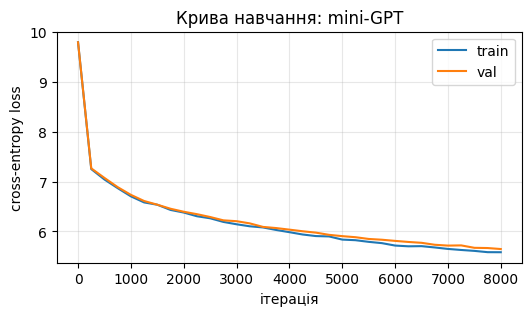

In [20]:
plt.figure(figsize=(6, 3))
plt.plot(checkpoint_iters, train_losses, label="train")
plt.plot(checkpoint_iters, val_losses, label="val")
plt.xlabel("ітерація"); plt.ylabel("cross-entropy loss"); plt.title("Крива навчання: mini-GPT")
plt.legend(); plt.grid(alpha=0.3)
plt.show()


### 3.10. Генерація на різних стадіях тренування

Порівнюємо якість тексту на першому збереженому чекпоінті (майже випадкова
ініціалізація) і на найкращому за val_loss (не обов'язково останньому —
модель могла почати переучуватись ближче до кінця тренування) — той самий
промпт в обох випадках.

In [21]:
def generate_text(state_dict_path: str, prompt: str, max_new_tokens: int = 40,
                   temperature: float = 0.8, top_k: int = 40) -> str:
    model.load_state_dict(torch.load(state_dict_path, map_location=device))
    prompt_ids = torch.tensor([encode(tokenize(prompt))], dtype=torch.long).to(device)
    out_ids = model.generate(prompt_ids, max_new_tokens, temperature=temperature, top_k=top_k)
    return decode(out_ids[0].tolist())


PROMPT = "Реве та стогне"

print("=== Ранній чекпоінт (iter", checkpoint_iters[0], ") ===")
print(generate_text(FIRST_CKPT_PATH, PROMPT))
print(f"\n=== Найкращий чекпоінт (iter {best_iter}, val_loss={best_val_loss:.3f}) ===")
print(generate_text(BEST_CKPT_PATH, PROMPT))

=== Ранній чекпоінт (iter 0 ) ===
Реве та стогнеалена тонкий мовив забир квит Нечкрип порів пих шкодаходило гостин геть дізнавсяВсе тек розпеч Едват доводилосьбудь повна рот револю Віктор дивились самою ВітчиВз хвіст станетьсявах Вітчиотом хатарузікочили шум підемо техні

=== Найкращий чекпоінт (iter 7999, val_loss=5.647) ===
Реве та стогне,
Коли в мене,
І не в його не може,
Дзвонили, що в нас на світі і ніч.

Ми, і всі на світ,
Та в землю


---
## 4. Sampling playground: готова модель

Власна mini-GPT замала, щоб переконливо демонструвати ефект temperature/
top-p — для цього візьмемо малу, але вже по-справжньому навчену відкриту
модель.

### 4.1. Завантажуємо готову модель

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-4B"

hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype="auto").to(device)
hf_model.eval()

print("Модель завантажено:", MODEL_ID)
print("Параметрів:", sum(p.numel() for p in hf_model.parameters()) / 1e6, "млн")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Модель завантажено: Qwen/Qwen3-4B
Параметрів: 4022.468096 млн


### 4.2. Той самий промпт, різна температура/top-p

Українська — не одна з офіційно заявлених мов цієї моделі, тому якість
може "плавати" — головне тут не ідеальність тексту, а те, як параметри
sampling міняють його характер.

In [6]:
def hf_generate(prompt: str, temperature: float, top_p: float, max_new_tokens: int = 300,
                enable_thinking: bool = False) -> str:
    messages = [{"role": "user", "content": prompt}]
    text = hf_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=enable_thinking
    )
    inputs = hf_tokenizer([text], return_tensors="pt").to(device)

    outputs = hf_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
    )
    return hf_tokenizer.decode(outputs[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True)


PLAYGROUND_PROMPT = "Продовж речення: Якось уночі студент " \
"Житомирської політехніки прокинувся від дивного шуму. Він підвівся з ліжка"

for temperature, top_p in [(0.2, 0.1), (0.8, 0.6), (1.4, 0.8)]:
    print(f"--- temperature={temperature}, top_p={top_p} ---")
    print(hf_generate(PLAYGROUND_PROMPT, temperature, top_p))
    print()

--- temperature=0.2, top_p=0.1 ---
Якось уночі студент Житомирської політехніки прокинувся від дивного шуму. Він підвівся з ліжка, зігнувся, намагався зрозуміти, чому так шумить, але здавалося, що нічого не відчуває, крім відчуття тривоги і незвичайної тишини, яка навколо нього виглядала навіть глибшою, ніж звичайно.

--- temperature=0.8, top_p=0.6 ---
Якось уночі студент Житомирської політехніки прокинувся від дивного шуму. Він підвівся з ліжка, зігнувся, намагався зрозуміти, чому так шумить, але навколо було тихо, лиш тільки вітер гудів через вікна. Він відкрив вікно, і він побачив, як на вулиці танцює білий вовнистий кіт, який здавався більш відомим, ніж самі студенти.

--- temperature=1.4, top_p=0.8 ---
Якось уночі студент Житомирської політехніки прокинувся від дивного шуму. Він підвівся з ліжка, засліпився яскравим світлом вибуху, що гудів з вікна. Студент розглянув уважно і побачив, що на підоконні висипав золотистий пламяст.



### 4.3. `enable_thinking=True` (завдання 0.1, п. 13)

Той самий промпт, але Qwen3 у режимі міркувань: спершу генерує блок `<think> … </think>`, потім відповідь. Ліміт `max_new_tokens` збільшено, інакше міркування можуть «з'їсти» весь бюджет. Для порівняння — той самий запуск з `enable_thinking=False`.

In [8]:
import time

for flag in (True, False):
    t0 = time.time()
    text = hf_generate(PLAYGROUND_PROMPT, temperature=0.8, top_p=0.6, max_new_tokens=700, enable_thinking=flag)
    print(f"--- enable_thinking={flag}  ({time.time() - t0:.0f} с, {len(hf_tokenizer(text)['input_ids'])} токенів) ---")
    print(text)
    print()

--- enable_thinking=True  (48 с, 700 токенів) ---
<think>
Okay, the user wants me to continue the sentence: "Якось уночі студент Житомирської політехніки прокинувся від дивного шуму. Він підвівся з ліжка..." So, first, I need to make sure I understand the context. The sentence is in Ukrainian, and it's about a student from the Kharkiv Polytechnic University (though the name is "Житомирської", which is Khmelnytskyi, not Kharkiv. Wait, maybe that's a mistake? Or maybe it's a different university. Anyway, the key is that the student is from a technical university in Khmelnytskyi.

The sentence starts with the student waking up from a strange noise. He gets up from bed. The next part should logically follow. So, what would a student do after waking up to a strange noise? Maybe he investigates the noise, checks the room, looks around, maybe finds something unusual. The story could take a supernatural or mysterious turn, or maybe it's a normal situation but with an unexpected twist.

I need 